In [1]:
import torch
import numpy as np 
import torch.nn as nn 
import torch.nn.functional as F 
import torch.optim as optim 
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt 

In [2]:
torch.manual_seed(20)

In [3]:
if torch.cuda.is_available():
    device = 'cuda'
    print('cuda available')
else:
    device = 'cpu'
    print('only cpu available')

cuda available


In [4]:
import torchvision
import torchvision.transforms as transforms

In [5]:
train_batch = 4
test_batch = 4

trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
trainloader = torch.utils.data.DataLoader(trainset, batch_size=train_batch, shuffle=True, num_workers=2)

testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transforms.ToTensor())
testloader = torch.utils.data.DataLoader(testset, batch_size=test_batch, shuffle=False, num_workers=2)

In [6]:
mean = trainset.data.float().mean()
std = trainset.data.float().std()

tform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[mean / 255.0], std=[std / 255.0])
])
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=tform)
testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=tform)

In [7]:
len(trainset), len(testset)

(60000, 10000)

In [8]:
trainloader = torch.utils.data.DataLoader(trainset, batch_size=train_batch, shuffle=True, num_workers=2)
testloader = torch.utils.data.DataLoader(testset, batch_size=test_batch, shuffle=False, num_workers=2)

In [9]:
trainset.data.shape 

torch.Size([60000, 28, 28])

In [10]:
trainset.targets.shape

torch.Size([60000])

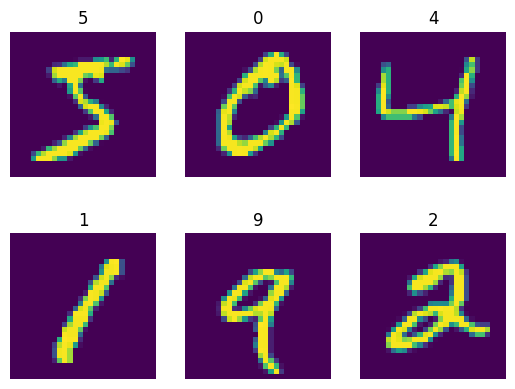

In [11]:
plt.figure()

for i in range(6):
    plt.subplot(2, 3, i+1) 
    plt.imshow(trainset.data[i])
    plt.title(f'{trainset.targets[i]}') 
    plt.axis('off')

In [12]:
class my_MLP(nn.Module):
    def __init__(self, ndim_in, hidden_dims, ndim_out, bias=True):
        """
        ndim_in (int): number of input features 
        hidden_dims (list): number of hidden units in each layer 
        ndim_out (int): number of output features 
        bias (boolean): whether to include a bias parameter
        """
        
        super().__init__() 
        self.mlp = nn.Sequential() 

        in_features = ndim_in
        for h in range(len(hidden_dims)):
            out_features = hidden_dims[h]
            self.mlp.add_module(f'Linear_{h}', nn.Linear(in_features, out_features, bias=bias))
            self.mlp.add_module(f'activation_{h}', nn.ReLU()) 
            in_features = out_features 

        self.mlp.add_module('Linear_output', nn.Linear(in_features, ndim_out, bias=bias))
        self.mlp.add_module('activation_output', nn.ReLU())

    def forward(self, x):
        return self.mlp(x) 

In [13]:
mlp = my_MLP(28*28, [20, 30, 20, 10, 5], 10).to(device)
mlp

my_MLP(
  (mlp): Sequential(
    (Linear_0): Linear(in_features=784, out_features=20, bias=True)
    (activation_0): ReLU()
    (Linear_1): Linear(in_features=20, out_features=30, bias=True)
    (activation_1): ReLU()
    (Linear_2): Linear(in_features=30, out_features=20, bias=True)
    (activation_2): ReLU()
    (Linear_3): Linear(in_features=20, out_features=10, bias=True)
    (activation_3): ReLU()
    (Linear_4): Linear(in_features=10, out_features=5, bias=True)
    (activation_4): ReLU()
    (Linear_output): Linear(in_features=5, out_features=10, bias=True)
    (activation_output): ReLU()
  )
)

In [14]:
optimizer = optim.SGD(params=mlp.parameters(), lr=1e-3)
loss_fn = F.cross_entropy 

train_loss = [] 
test_loss = [] 
train_acc = [] 
test_acc = [] 

In [15]:
def train():
    mlp.train() 
    running_loss = 0 
    correct_preds = 0 

    for data, label in trainloader:
        data, label = data.to(device), label.to(device)

        # forward pass 
        logits = mlp(data.view(data.shape[0], -1)) 
        loss = loss_fn(logits, label) 

        # back-propagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step() 

        running_loss += loss.item() 

        # prediction accuracy
        pred_label = logits.argmax(axis=1) 
        correct_preds += (pred_label == label).sum() 

    train_loss.append(running_loss / len(trainloader)) 
    train_acc.append(correct_preds / len(trainset)) 

In [16]:
def test():
    mlp.eval() 
    running_loss = 0 
    correct_preds = 0 

    for data, label in testloader:
        data, label = data.to(device), label.to(device)

        with torch.no_grad():
            logits = mlp(data.view(data.shape[0], -1)) 
            loss = loss_fn(logits, label)

            running_loss += loss.item() 
            pred_label = logits.argmax(axis=1)
            correct_preds += (pred_label == label).sum() 

    test_loss.append(running_loss / len(testloader))
    test_acc.append(correct_preds / len(testset)) 

In [17]:
n_epochs = 100 

for epochI in range(n_epochs):
    print(f'epoch: {epochI}')
    train() 
    test() 

epoch: 0
epoch: 1
epoch: 2
epoch: 3
epoch: 4
epoch: 5
epoch: 6
epoch: 7
epoch: 8
epoch: 9
epoch: 10
epoch: 11
epoch: 12
epoch: 13
epoch: 14
epoch: 15
epoch: 16
epoch: 17
epoch: 18
epoch: 19
epoch: 20
epoch: 21
epoch: 22
epoch: 23
epoch: 24
epoch: 25
epoch: 26
epoch: 27
epoch: 28
epoch: 29
epoch: 30
epoch: 31
epoch: 32
epoch: 33
epoch: 34
epoch: 35
epoch: 36
epoch: 37
epoch: 38
epoch: 39
epoch: 40
epoch: 41
epoch: 42
epoch: 43
epoch: 44
epoch: 45
epoch: 46
epoch: 47
epoch: 48
epoch: 49
epoch: 50
epoch: 51
epoch: 52
epoch: 53
epoch: 54
epoch: 55
epoch: 56
epoch: 57
epoch: 58
epoch: 59
epoch: 60
epoch: 61
epoch: 62
epoch: 63
epoch: 64
epoch: 65
epoch: 66
epoch: 67
epoch: 68
epoch: 69
epoch: 70
epoch: 71
epoch: 72
epoch: 73
epoch: 74
epoch: 75
epoch: 76
epoch: 77
epoch: 78
epoch: 79
epoch: 80
epoch: 81
epoch: 82
epoch: 83
epoch: 84
epoch: 85
epoch: 86
epoch: 87
epoch: 88
epoch: 89
epoch: 90
epoch: 91
epoch: 92
epoch: 93
epoch: 94
epoch: 95
epoch: 96
epoch: 97
epoch: 98
epoch: 99


In [18]:
train_loss 

[2.2858766455173494,
 1.9748370736082395,
 1.4137582642008861,
 0.840873925072824,
 0.6217289855524122,
 0.4614867229762177,
 0.30275595580086423,
 0.2543741325308608,
 0.22524261965135423,
 0.2027958678758315,
 0.18694302901425155,
 0.17640283644972152,
 0.1651855499443819,
 0.1575562908634199,
 0.15062868615247582,
 0.14242480526553114,
 0.13935455679494352,
 0.13545337362805737,
 0.1291693699057646,
 0.12603087645806943,
 0.12276443527592439,
 0.11892078709283527,
 0.1158608074334017,
 0.11325962444506137,
 0.1091270628536466,
 0.10579834990166767,
 0.10406684619578045,
 0.1003443750604691,
 0.09957427668435373,
 0.09685827511264644,
 0.09622634545537576,
 0.09146901256043824,
 0.09002240997677624,
 0.08949489739772798,
 0.08602621194763053,
 0.08494499258979514,
 0.0834317710847201,
 0.08190663798011573,
 0.0809338397844294,
 0.07807936512231674,
 0.07714773963756388,
 0.07566386869616949,
 0.07596584221156696,
 0.07255862116699281,
 0.07212008105979209,
 0.07155728571036296,
 0.07

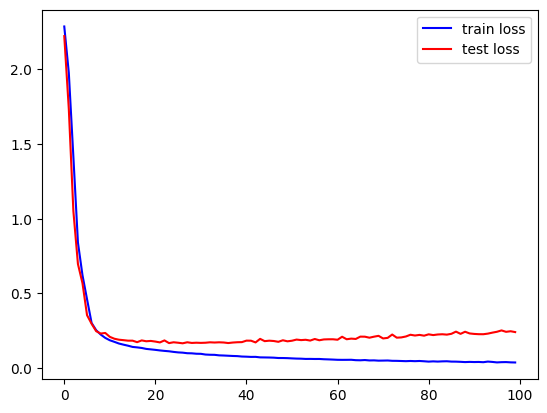

In [19]:
plt.figure() 

plt.plot(train_loss, '-', color='b', label='train loss')
plt.plot(test_loss, '-', color='r', label='test loss')
plt.legend()

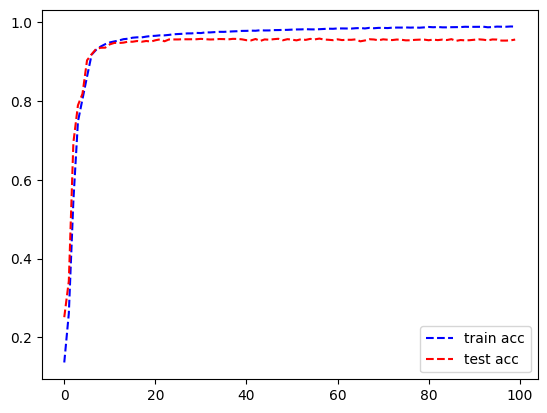

In [20]:
plt.figure() 

plt.plot([x.cpu() for x in train_acc], '--', color='b', label='train acc')
plt.plot([x.cpu() for x in test_acc], '--', color='r', label='test acc')
plt.legend() 

In [21]:
train_acc 

[tensor(0.1365, device='cuda:0'),
 tensor(0.2609, device='cuda:0'),
 tensor(0.5465, device='cuda:0'),
 tensor(0.7474, device='cuda:0'),
 tensor(0.8046, device='cuda:0'),
 tensor(0.8615, device='cuda:0'),
 tensor(0.9171, device='cuda:0'),
 tensor(0.9296, device='cuda:0'),
 tensor(0.9378, device='cuda:0'),
 tensor(0.9438, device='cuda:0'),
 tensor(0.9482, device='cuda:0'),
 tensor(0.9508, device='cuda:0'),
 tensor(0.9532, device='cuda:0'),
 tensor(0.9565, device='cuda:0'),
 tensor(0.9577, device='cuda:0'),
 tensor(0.9603, device='cuda:0'),
 tensor(0.9612, device='cuda:0'),
 tensor(0.9610, device='cuda:0'),
 tensor(0.9630, device='cuda:0'),
 tensor(0.9644, device='cuda:0'),
 tensor(0.9650, device='cuda:0'),
 tensor(0.9662, device='cuda:0'),
 tensor(0.9662, device='cuda:0'),
 tensor(0.9674, device='cuda:0'),
 tensor(0.9689, device='cuda:0'),
 tensor(0.9696, device='cuda:0'),
 tensor(0.9701, device='cuda:0'),
 tensor(0.9711, device='cuda:0'),
 tensor(0.9712, device='cuda:0'),
 tensor(0.9725